<a href="https://colab.research.google.com/github/Tejaswimadastu/Machine_Learning/blob/main/Ensemble/XG_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌳 1️⃣ n_estimators → Number of Trees

👉 How many trees to build

100 → 100 trees

500 → 500 trees

✅ More trees = better learning
❌ Too many = slow & overfitting

⚡ 2️⃣ learning_rate → Strength of Learning

👉 How much each tree contributes

Value	Meaning
0.1	Standard
0.01	Slow but accurate
0.3	Fast but risky

👉 Think: Step size in learning

🌲 3️⃣ max_depth → Depth of Each Tree

👉 How complex each tree is

3 → small tree (good)

10 → big tree (overfit risk)

✅ Small depth = generalization
❌ Large depth = memorize data

🎯 4️⃣ subsample → Rows Used

👉 Percentage of training samples used per tree

Value	Meaning
1.0	use all data
0.8	use 80% random rows

✅ Helps reduce overfitting
👉 Similar to bagging in Random Forest

🧩 5️⃣ colsample_bytree → Features Used

👉 Percentage of features per tree

Value	Meaning
1.0	all features
0.7	70% features

✅ Adds randomness
✅ Reduces correlation

In [1]:
import pandas as pd
df=pd.read_csv('Social_Network_Ads.csv')

In [2]:
X = df.iloc[:, [2, 3]].values   # Age, Salary columns
y = df.iloc[:, -1].values       # Target column (Purchased)


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [6]:
from xgboost import XGBClassifier
classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

classifier.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
y_pred = classifier.predict(X_test)


In [8]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9


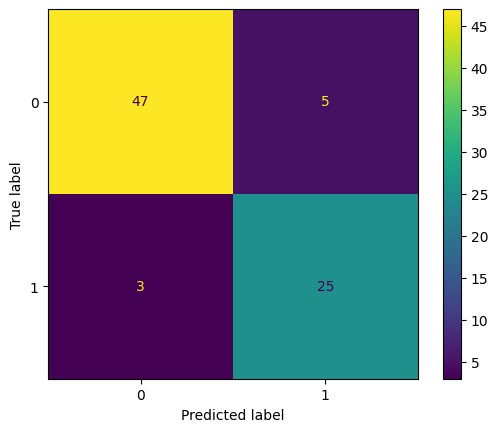

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
